# Inference Time Comparison

Read `assets/inference_time_per_frame.csv` and compare GPU-only per-frame inference time across models and datasets.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "analysis":
    ROOT = ROOT.parent

CSV_PATH = ROOT / "assets" / "inference_time_per_frame.csv"
OUTPUT_DIR = ROOT / "analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_ORDER = ["UNet", "SuperSloMo", "EDEN", "FLEX"]
DATASET_ORDER = ["NSKT", "Shanghai", "SST"]
MODEL_COLORS = {
    "UNet": "#0072B2",
    "SuperSloMo": "#009E73",
    "EDEN": "#CC79A7",
    "FLEX": "#D55E00",
}


TIME_COLUMN = "milliseconds_per_sample_frame"
TIME_STD_COLUMN = "std_milliseconds_per_sample_frame"
TIME_LABEL = "Inference time per sample frame (ms)"


def first_available_column(frame, candidates):
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"Missing all candidate columns: {candidates}")


df = pd.read_csv(CSV_PATH)
df["dataset"] = df["data_name"].replace({
    "nskt": "NSKT",
    "shanghai": "Shanghai",
    "sea_temp": "SST",
    "sst": "SST",
})

# Older benchmark rows only have `mean_seconds_per_frame`, which measured one
# generated interpolation step for the whole batch. Normalize by batch size so
# every plot reports per-sample per-frame time.
mean_sample_seconds_col = first_available_column(
    df,
    ["mean_seconds_per_sample_frame", "mean_seconds_per_frame"],
)
std_sample_seconds_col = first_available_column(
    df,
    ["std_seconds_per_sample_frame", "std_seconds_per_frame"],
)
median_sample_seconds_col = first_available_column(
    df,
    ["median_seconds_per_sample_frame", "median_seconds_per_frame"],
)

if mean_sample_seconds_col == "mean_seconds_per_frame":
    df["mean_seconds_per_sample_frame"] = df["mean_seconds_per_frame"] / df["batch_size"]
    df["std_seconds_per_sample_frame"] = df["std_seconds_per_frame"] / df["batch_size"]
    df["median_seconds_per_sample_frame"] = df["median_seconds_per_frame"] / df["batch_size"]
else:
    # Fill any older appended rows that may coexist with newer rows.
    df["mean_seconds_per_sample_frame"] = df["mean_seconds_per_sample_frame"].fillna(
        df["mean_seconds_per_frame"] / df["batch_size"]
    )
    df["std_seconds_per_sample_frame"] = df["std_seconds_per_sample_frame"].fillna(
        df["std_seconds_per_frame"] / df["batch_size"]
    )
    df["median_seconds_per_sample_frame"] = df["median_seconds_per_sample_frame"].fillna(
        df["median_seconds_per_frame"] / df["batch_size"]
    )

# Keep batch-level columns for auditing, but use sample-normalized columns for comparison.
df["milliseconds_per_batch_frame"] = 1000.0 * df["mean_seconds_per_frame"]
df["std_milliseconds_per_batch_frame"] = 1000.0 * df["std_seconds_per_frame"]
df["milliseconds_per_sample_frame"] = 1000.0 * df["mean_seconds_per_sample_frame"]
df["std_milliseconds_per_sample_frame"] = 1000.0 * df["std_seconds_per_sample_frame"]
df["median_milliseconds_per_sample_frame"] = 1000.0 * df["median_seconds_per_sample_frame"]

# Backward-compatible aliases used by older cells; these now refer to sample-normalized time.
df["milliseconds_per_frame"] = df["milliseconds_per_sample_frame"]
df["std_milliseconds_per_frame"] = df["std_milliseconds_per_sample_frame"]

df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)

print(f"Loaded {len(df)} benchmark rows from {CSV_PATH}")
print("Using sample-normalized timing: mean_seconds_per_sample_frame = mean_seconds_per_frame / batch_size for older rows.")
display(df.sort_values(["dataset", "model", "checkpoint_path"]))


Loaded 18 benchmark rows from /pscratch/sd/p/puren93/puren/Interp-DM/assets/inference_time_per_frame.csv
Using sample-normalized timing: mean_seconds_per_sample_frame = mean_seconds_per_frame / batch_size for older rows.


,model,data_name,run_name,checkpoint_path,total_interp_steps,batch_size,warmup_batches,timed_batches,mean_seconds_per_frame,std_seconds_per_frame,...,mean_seconds_per_sample_frame,std_seconds_per_sample_frame,median_seconds_per_sample_frame,milliseconds_per_batch_frame,std_milliseconds_per_batch_frame,milliseconds_per_sample_frame,std_milliseconds_per_sample_frame,median_milliseconds_per_sample_frame,milliseconds_per_frame,std_milliseconds_per_frame
0,UNet,nskt,Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_ep...,checkpoints/checkpoint_Model_UNet_Data_nskt_Op...,20,12,2,20,0.352752,0.000447,...,0.029396,0.000037,0.029406,352.752082,0.446571,29.396007,0.037214,29.405964,29.396007,0.037214
3,UNet,nskt,Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_ep...,checkpoints/checkpoint_Model_UNet_Data_nskt_Op...,20,12,2,20,0.353212,0.000418,...,0.029434,0.000035,0.029434,353.212068,0.417670,29.434339,0.034806,29.434493,29.434339,0.034806
6,UNet,nskt,Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_ep...,checkpoints/checkpoint_Model_UNet_Data_nskt_Op...,20,12,2,20,0.352850,0.000502,...,0.029404,0.000042,0.029403,352.850404,0.502149,29.404200,0.041846,29.403058,29.404200,0.041846
1,SuperSloMo,nskt,Model_ft_SuperSloMo_Data_nskt_Optim_adam_lr6e-...,checkpoints/checkpoint_Model_SuperSloMo_Data_n...,20,64,2,20,0.226403,0.002172,...,0.003538,0.000034,0.003521,226.403474,2.171665,3.537554,0.033932,3.521085,3.537554,0.033932
4,SuperSloMo,nskt,Model_ft_SuperSloMo_Data_nskt_Optim_adam_lr6e-...,checkpoints/checkpoint_Model_SuperSloMo_Data_n...,20,64,2,20,0.226505,0.002005,...,0.003539,0.000031,0.003522,226.505351,2.004978,3.539146,0.031328,3.521730,3.539146,0.031328
7,SuperSloMo,nskt,Model_ft_SuperSloMo_Data_nskt_Optim_adam_lr6e-...,checkpoints/checkpoint_Model_SuperSloMo_Data_n...,20,64,2,20,0.226158,0.001767,...,0.003534,0.000028,0.003520,226.158422,1.767181,3.533725,0.027612,3.520064,3.533725,0.027612
15,EDEN,nskt,EDEN_Data_nskt_patch256_T20,vae=/pscratch/sd/p/puren93/puren/Interp-DM/EDE...,20,32,2,6,0.305006,0.000052,...,0.009531,0.000002,0.009531,305.006438,0.051505,9.531451,0.001610,9.531060,9.531451,0.001610
2,FLEX,nskt,Model_ft_FLEX_small_mlp2_Data_nskt_Optim_adam_...,checkpoints/checkpoint_Model_ft_FLEX3_small_ml...,20,12,2,20,0.424803,0.000083,...,0.035400,0.000007,0.035402,424.802652,0.082645,35.400221,0.006887,35.401800,35.400221,0.006887
5,FLEX,nskt,Model_ft_FLEX_small_mlp2_Data_nskt_Optim_adam_...,checkpoints/checkpoint_Model_ft_FLEX3_small_ml...,20,12,2,20,0.424572,0.000061,...,0.035381,0.000005,0.035382,424.571884,0.061045,35.380990,0.005087,35.382072,35.380990,0.005087
8,FLEX,nskt,Model_ft_FLEX_small_mlp2_Data_nskt_Optim_adam_...,checkpoints/checkpoint_Model_ft_FLEX3_small_ml...,20,12,2,20,0.424667,0.000068,...,0.035389,0.000006,0.035389,424.667371,0.067824,35.388948,0.005652,35.389127,35.388948,0.005652


## Aggregate Repeated Runs

If a model/dataset pair was benchmarked more than once, this table averages those repeated benchmark rows. `run_std_ms` is the standard deviation across repeated benchmark means, not the within-run CUDA-event standard deviation.

In [2]:
summary = (
    df.groupby(["dataset", "model"], observed=True)
    .agg(
        runs=(TIME_COLUMN, "size"),
        mean_ms=(TIME_COLUMN, "mean"),
        run_std_ms=(TIME_COLUMN, "std"),
        median_ms=(TIME_COLUMN, "median"),
        mean_within_run_std_ms=(TIME_STD_COLUMN, "mean"),
        mean_batch_frame_ms=("milliseconds_per_batch_frame", "mean"),
        timed_batches=("timed_batches", "mean"),
        batch_sizes=("batch_size", lambda values: ", ".join(map(str, sorted(set(values))))),
    )
    .reset_index()
)
summary["run_std_ms"] = summary["run_std_ms"].fillna(0.0)
summary["dataset"] = pd.Categorical(summary["dataset"], categories=DATASET_ORDER, ordered=True)
summary["model"] = pd.Categorical(summary["model"], categories=MODEL_ORDER, ordered=True)
summary = summary.sort_values(["dataset", "model"])

print("All comparison columns below are per-sample per-frame milliseconds.")
display(summary)
display(summary.pivot(index="dataset", columns="model", values="mean_ms").round(3))


All comparison columns below are per-sample per-frame milliseconds.


,dataset,model,runs,mean_ms,run_std_ms,median_ms,mean_within_run_std_ms,mean_batch_frame_ms,timed_batches,batch_sizes
0,NSKT,UNet,3,29.411515,0.020186,29.404200,0.037955,352.938184,20.0,12
1,NSKT,SuperSloMo,3,3.536809,0.002786,3.537554,0.030957,226.355749,20.0,64
2,NSKT,EDEN,1,9.531451,0.000000,9.531451,0.001610,305.006438,6.0,32
3,NSKT,FLEX,3,35.390053,0.009663,35.388948,0.005875,424.680636,20.0,12
4,Shanghai,UNet,1,13.253762,0.000000,13.253762,0.121053,159.045144,20.0,12
5,Shanghai,SuperSloMo,1,1.452805,0.000000,1.452805,0.036400,46.489762,20.0,32
6,Shanghai,EDEN,1,2.323575,0.000000,2.323575,0.450069,148.708820,12.0,64
7,Shanghai,FLEX,1,10.533390,0.000000,10.533390,0.004040,126.400680,20.0,12
8,SST,UNet,1,13.269280,0.000000,13.269280,0.229585,212.308485,20.0,16
9,SST,SuperSloMo,1,1.451842,0.000000,1.451842,0.031377,46.458951,20.0,32


model,UNet,SuperSloMo,EDEN,FLEX
dataset,,,,
NSKT,29.412,3.537,9.531,35.390
Shanghai,13.254,1.453,2.324,10.533
SST,13.269,1.452,2.454,9.352


## Grouped Bar Chart

Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/inference_time_per_frame_grouped_bar.png
Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/inference_time_per_frame_grouped_bar.pdf


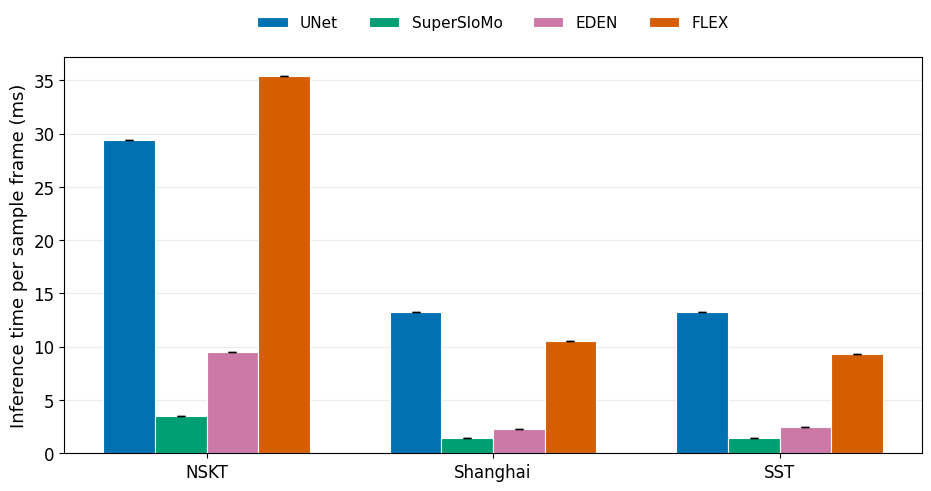

In [3]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

pivot = summary.pivot(index="dataset", columns="model", values="mean_ms").reindex(DATASET_ORDER)
err = summary.pivot(index="dataset", columns="model", values="run_std_ms").reindex(DATASET_ORDER)

fig, ax = plt.subplots(figsize=(9.2, 4.8), constrained_layout=True)
x = np.arange(len(DATASET_ORDER))
width = 0.18
offsets = (np.arange(len(MODEL_ORDER)) - (len(MODEL_ORDER) - 1) / 2) * width

for offset, model in zip(offsets, MODEL_ORDER):
    if model not in pivot.columns:
        continue
    values = pivot[model].to_numpy(dtype=float)
    yerr = err[model].to_numpy(dtype=float) if model in err.columns else None
    ax.bar(
        x + offset,
        values,
        width,
        yerr=yerr,
        capsize=3,
        label=model,
        color=MODEL_COLORS[model],
        edgecolor="white",
        linewidth=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels(DATASET_ORDER)
ax.set_ylabel(TIME_LABEL)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.14))

output_png = OUTPUT_DIR / "inference_time_per_frame_grouped_bar.png"
output_pdf = OUTPUT_DIR / "inference_time_per_frame_grouped_bar.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved {output_png}")
print(f"Saved {output_pdf}")
plt.show()


## Per-Dataset Ranking

Lower is faster. `speedup_vs_slowest` is computed within each dataset.

In [4]:
ranking = summary.copy()
ranking["rank"] = ranking.groupby("dataset", observed=True)["mean_ms"].rank(method="dense")
slowest = ranking.groupby("dataset", observed=True)["mean_ms"].transform("max")
fastest = ranking.groupby("dataset", observed=True)["mean_ms"].transform("min")
ranking["speedup_vs_slowest"] = slowest / ranking["mean_ms"]
ranking["slowdown_vs_fastest"] = ranking["mean_ms"] / fastest
ranking = ranking.sort_values(["dataset", "rank"])

display(
    ranking[[
        "dataset", "rank", "model", "mean_ms", "run_std_ms",
        "speedup_vs_slowest", "slowdown_vs_fastest", "batch_sizes", "runs",
    ]].round({
        "mean_ms": 2,
        "run_std_ms": 2,
        "speedup_vs_slowest": 2,
        "slowdown_vs_fastest": 2,
    })
)

,dataset,rank,model,mean_ms,run_std_ms,speedup_vs_slowest,slowdown_vs_fastest,batch_sizes,runs
1,NSKT,1.0,SuperSloMo,3.54,0.00,10.01,1.00,64,3
2,NSKT,2.0,EDEN,9.53,0.00,3.71,2.69,32,1
0,NSKT,3.0,UNet,29.41,0.02,1.20,8.32,12,3
3,NSKT,4.0,FLEX,35.39,0.01,1.00,10.01,12,3
5,Shanghai,1.0,SuperSloMo,1.45,0.00,9.12,1.00,32,1
6,Shanghai,2.0,EDEN,2.32,0.00,5.70,1.60,64,1
7,Shanghai,3.0,FLEX,10.53,0.00,1.26,7.25,12,1
4,Shanghai,4.0,UNet,13.25,0.00,1.00,9.12,12,1
9,SST,1.0,SuperSloMo,1.45,0.00,9.14,1.00,32,1
10,SST,2.0,EDEN,2.45,0.00,5.41,1.69,64,1


## Heatmap

Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/inference_time_per_frame_heatmap.png
Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/inference_time_per_frame_heatmap.pdf


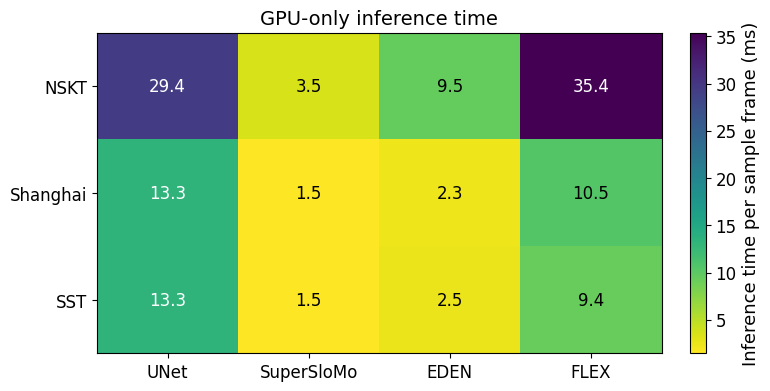

In [5]:
heatmap = pivot.reindex(columns=MODEL_ORDER)

fig, ax = plt.subplots(figsize=(7.6, 3.8), constrained_layout=True)
im = ax.imshow(heatmap.to_numpy(dtype=float), cmap="viridis_r", aspect="auto")

ax.set_xticks(np.arange(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(np.arange(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

for i, dataset in enumerate(heatmap.index):
    for j, model in enumerate(heatmap.columns):
        value = heatmap.loc[dataset, model]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="white" if value > np.nanmean(heatmap.values) else "black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(TIME_LABEL)
ax.set_title("GPU-only inference time")

output_png = OUTPUT_DIR / "inference_time_per_frame_heatmap.png"
output_pdf = OUTPUT_DIR / "inference_time_per_frame_heatmap.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved {output_png}")
print(f"Saved {output_pdf}")
plt.show()


## NSKT Accuracy-Efficiency Bubble Plot

This plot follows `accuracy_efficiency_bubble_plot.ipynb`: x-axis is GPU-only inference time per frame, y-axis is RFNE, and bubble area is scaled by parameter count. Lower-left is better.


,model,plot_label,rfne_pct,params_m,mean_ms,run_std_ms,runs,batch_sizes,inference_time_s,inference_time_std_s
1,SuperSloMo,Super SloMo,14.93,39.59,3.536809,0.002786,3,64,3.536809,0.002786
2,EDEN,EDEN,12.53,194.00,9.531451,0.000000,1,32,9.531451,0.000000
0,UNet,U-Net,34.07,260.33,29.411515,0.020186,3,12,29.411515,0.020186
3,FLEX,CT-FLEX,3.79,110.20,35.390053,0.009663,3,12,35.390053,0.009663


Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_accuracy_efficiency_bubble_plot.pdf
Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_accuracy_efficiency_bubble_plot.png


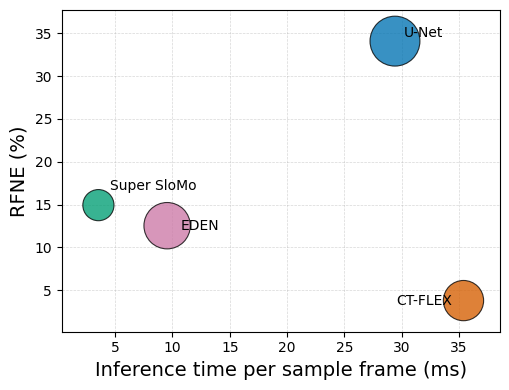

In [6]:
# NSKT accuracy-efficiency example using sample-normalized inference time.
# RFNE values are from the NSKT Re=36000 / T=20-style comparison used in the RFNE notebooks.
# Update these numbers if you want to compare a different Reynolds number or evaluation step count.
nskt_accuracy = pd.DataFrame(
    {
        "model": ["UNet", "SuperSloMo", "EDEN", "FLEX"],
        "plot_label": ["U-Net", "Super SloMo", "EDEN", "CT-FLEX"],
        "rfne_pct": [34.07, 14.93, 12.53, 3.79],
        "params_m": [260.33, 39.59, 194.00, 110.20],
    }
)

nskt_timing = summary[summary["dataset"] == "NSKT"][["model", "mean_ms", "run_std_ms", "runs", "batch_sizes"]].copy()
nskt_bubble = nskt_accuracy.merge(nskt_timing, on="model", how="left")
# nskt_bubble["inference_time_s"] = nskt_bubble["mean_ms"] / 1000.0
# nskt_bubble["inference_time_std_s"] = nskt_bubble["run_std_ms"] / 1000.0

nskt_bubble["inference_time_s"] = nskt_bubble["mean_ms"]
nskt_bubble["inference_time_std_s"] = nskt_bubble["run_std_ms"]

missing = nskt_bubble[nskt_bubble["inference_time_s"].isna()]
if not missing.empty:
    raise ValueError(f"Missing NSKT timing rows for: {missing['model'].tolist()}")

nskt_bubble = nskt_bubble.sort_values("inference_time_s")
display(nskt_bubble)

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 14,
        "axes.titlesize": 13,
        "legend.fontsize": 9,
        "legend.title_fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

models = nskt_bubble["plot_label"].to_numpy()
inference_time = nskt_bubble["inference_time_s"].to_numpy(dtype=float)
rfne = nskt_bubble["rfne_pct"].to_numpy(dtype=float)
params_m = nskt_bubble["params_m"].to_numpy(dtype=float)
colors = [MODEL_COLORS[model] for model in nskt_bubble["model"]]

# Sqrt scaling keeps large models from visually dominating the figure.
bubble_size = 80 * np.sqrt(params_m)

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.scatter(
    inference_time,
    rfne,
    s=bubble_size,
    c=colors,
    alpha=0.78,
    edgecolors="black",
    linewidths=0.8,
)

label_offsets = {
    "U-Net": (6, 6),
    "Super SloMo": (8, 14),
    "EDEN": (10, 0),
    "CT-FLEX": (-8, 0),
}
label_align = {
    "CT-FLEX": "right",
}

for model, x, y in zip(models, inference_time, rfne):
    ax.annotate(
        model,
        (x, y),
        textcoords="offset points",
        xytext=label_offsets.get(model, (6, 5)),
        ha=label_align.get(model, "left"),
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Inference time per sample frame (ms)")
ax.set_ylabel("RFNE (%)")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

x_margin = 0.10 * (inference_time.max() - inference_time.min() + 1e-8)
y_margin = 0.12 * (rfne.max() - rfne.min() + 1e-8)
ax.set_xlim(inference_time.min() - x_margin, inference_time.max() + x_margin)
ax.set_ylim(rfne.min() - y_margin, rfne.max() + y_margin)

fig.tight_layout()

pdf_path = OUTPUT_DIR / "nskt_accuracy_efficiency_bubble_plot.pdf"
png_path = OUTPUT_DIR / "nskt_accuracy_efficiency_bubble_plot.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved {pdf_path}")
print(f"Saved {png_path}")
plt.show()
